In [2]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED']       = '123'

import random
random.seed(123)

import numpy as np
np.random.seed(123)

import tensorflow as tf
tf.random.set_seed(123)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
fdir = "/kaggle/input/datasets/abdulkatsir/datset/siputLaut"

filepaths = []
labels = []
classlist = os.listdir(fdir)
for klass in classlist:
    classpath = os.path.join(fdir, klass)
    if os.path.isdir(classpath):
        flist = os.listdir(classpath)
        for f in flist:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.webp')):
                fpath = os.path.join(classpath, f)
                filepaths.append(fpath)
                labels.append(klass)

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')

df = pd.concat([Fseries, Lseries], axis=1)
print(df.head())
print(df['labels'].value_counts())

                                           filepaths         labels
0  /kaggle/input/datasets/abdulkatsir/datset/sipu...  Nerita undata
1  /kaggle/input/datasets/abdulkatsir/datset/sipu...  Nerita undata
2  /kaggle/input/datasets/abdulkatsir/datset/sipu...  Nerita undata
3  /kaggle/input/datasets/abdulkatsir/datset/sipu...  Nerita undata
4  /kaggle/input/datasets/abdulkatsir/datset/sipu...  Nerita undata
labels
Nerita undata          425
Planaxis sulcatus      425
Nerita melanotragus    425
Name: count, dtype: int64


In [4]:
train_split = .70
test_split = .15
dummy_split = test_split / (1 - train_split)

train_df, dummy_df = train_test_split(
    df, 
    train_size=train_split, 
    shuffle=True, 
    random_state=123,
    stratify     = df['labels'] 
)
valid_df, test_df = train_test_split(
    dummy_df, 
    train_size=dummy_split, 
    shuffle=True, 
    random_state=123,
    stratify     = dummy_df['labels']
)

print('train_df:', len(train_df), ' valid_df:', len(valid_df), ' test_df:', len(test_df))

train_df: 892  valid_df: 191  test_df: 192


In [5]:
print("=" * 50)
print("DISTRIBUSI DATA PER KELAS")
print("=" * 50)

print("\nTrain Set:")
print(train_df['labels'].value_counts())

print("\nValidation Set:")
print(valid_df['labels'].value_counts())

print("\nTest Set:")
print(test_df['labels'].value_counts())

print("\n" + "=" * 50)
print("TOTAL PER SET:")
print(f"Train      : {len(train_df)} gambar")
print(f"Validation : {len(valid_df)} gambar")
print(f"Test       : {len(test_df)} gambar")
print(f"Total      : {len(df)} gambar")
print("=" * 50)

DISTRIBUSI DATA PER KELAS

Train Set:
labels
Nerita melanotragus    298
Planaxis sulcatus      297
Nerita undata          297
Name: count, dtype: int64

Validation Set:
labels
Nerita undata          64
Planaxis sulcatus      64
Nerita melanotragus    63
Name: count, dtype: int64

Test Set:
labels
Planaxis sulcatus      64
Nerita undata          64
Nerita melanotragus    64
Name: count, dtype: int64

TOTAL PER SET:
Train      : 892 gambar
Validation : 191 gambar
Test       : 192 gambar
Total      : 1275 gambar


In [6]:
height     = 224
width      = 224
channels   = 3
batch_size = 32

img_shape  = (height, width, channels)
img_size   = (height, width)


length = len(test_df)
test_batch_size = sorted([int(length/n) for n in range(1, length+1)
                          if length % n == 0 and length/n <= 80], reverse=True)[0]
test_steps = int(length / test_batch_size)
print('test batch size:', test_batch_size, ' test steps:', test_steps)


train_gen_flow = ImageDataGenerator(
    rescale          = 1./255,
    rotation_range   = 10,
    zoom_range       = 0.15,
    horizontal_flip  = True,
    brightness_range = [0.8, 1.2],
    shear_range      = 0.1,
    fill_mode        = 'nearest'
)

val_test_gen_flow = ImageDataGenerator(rescale=1./255)


train_gen = train_gen_flow.flow_from_dataframe(
    train_df,
    x_col       = 'filepaths',
    y_col       = 'labels',
    target_size = img_size,
    class_mode  = 'categorical',
    color_mode  = 'rgb',
    shuffle     = True,
    batch_size  = batch_size,
    seed        = 123
)

valid_gen = val_test_gen_flow.flow_from_dataframe(
    valid_df,
    x_col       = 'filepaths',
    y_col       = 'labels',
    target_size = img_size,
    class_mode  = 'categorical',
    color_mode  = 'rgb',
    shuffle     = True,
    batch_size  = batch_size,
    seed        = 123
)

test_gen = val_test_gen_flow.flow_from_dataframe(
    test_df,
    x_col       = 'filepaths',
    y_col       = 'labels',
    target_size = img_size,
    class_mode  = 'categorical',
    color_mode  = 'rgb',
    shuffle     = False,
    batch_size  = test_batch_size
)

classes     = list(train_gen.class_indices.keys())
class_count = len(classes)
print('Jumlah kelas :', class_count)
print('Kelas        :', classes)

test batch size: 64  test steps: 3
Found 892 validated image filenames belonging to 3 classes.
Found 191 validated image filenames belonging to 3 classes.
Found 192 validated image filenames belonging to 3 classes.
Jumlah kelas : 3
Kelas        : ['Nerita melanotragus', 'Nerita undata', 'Planaxis sulcatus']


In [ ]:
def show_image_samples(gen):
    classes = list(gen.class_indices.keys())
    images, labels = next(gen)
    plt.figure(figsize=(25, 25))
    r = min(25, len(labels))
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i])
        index = np.argmax(labels[i])
        plt.title(classes[index], color='blue', fontsize=12)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen)

In [8]:
tf.keras.backend.clear_session()
tf.random.set_seed(123)
np.random.seed(123)

base_model = tf.keras.applications.VGG16(
    include_top  = False,
    weights      = "imagenet",
    input_tensor = Input(shape=(224, 224, 3))
)
base_model.trainable = False
base_model.summary()


model_name='AbdulKatsir'
print("Building model with", base_model)

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2, strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(class_count, activation='softmax')
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 7, 7, 256)      │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,915 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,901,507 (60.66 MB)

 Trainable params: 1,186,819 (4.53 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
early_stop = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1
)

epochs = 30

history = model.fit(
    x               = train_gen,
    epochs          = epochs,
    validation_data = valid_gen,
    callbacks       = [early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1782809072.972055     137 cuda_dnn.cc:529] Loaded cuDNN version 91002


28/28 ━━━━━━━━━━━━━━━━━━━━ 200s 7s/step - accuracy: 0.5540 - loss: 1.4411 - val_accuracy: 0.8953 - val_loss: 0.3282
Epoch 2/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.8713 - loss: 0.3322 - val_accuracy: 0.8796 - val_loss: 0.2859
Epoch 3/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.8916 - loss: 0.2488 - val_accuracy: 0.9162 - val_loss: 0.2222
Epoch 4/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 133s 5s/step - accuracy: 0.9307 - loss: 0.1757 - val_accuracy: 0.9267 - val_loss: 0.1610
Epoch 5/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.9353 - loss: 0.1561 - val_accuracy: 0.9319 - val_loss: 0.1669
Epoch 6/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 134s 5s/step - accuracy: 0.9173 - loss: 0.2039 - val_accuracy: 0.8953 - val_loss: 0.2110
Epoch 7/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 135s 5s/step - accuracy: 0.9485 - loss: 0.1365 - val_accuracy: 0.9476 - val_loss: 0.1248
Epoch 8/30
28/28 ━━━━━━━━━━━━━━━━━━━━ 140s 5s/step - accuracy: 0.9488 - loss: 0.1214 - val_accuracy: 0.9319 - val_loss: 0.

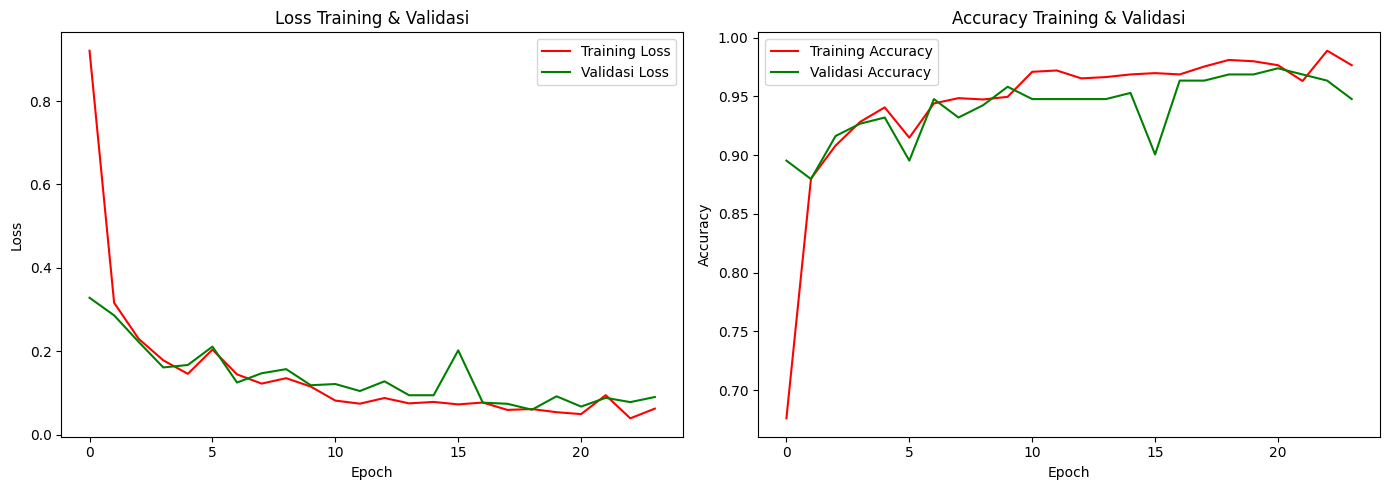

In [10]:
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], 
                 label='Training Loss', color='red')
    axes[0].plot(history.history['val_loss'], 
                 label='Validasi Loss', color='green')
    axes[0].set_title('Loss Training & Validasi')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], 
                 label='Training Accuracy', color='red')
    axes[1].plot(history.history['val_accuracy'], 
                 label='Validasi Accuracy', color='green')
    axes[1].set_title('Accuracy Training & Validasi')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [12]:

def print_info(test_gen, preds, print_code, save_dir, subject):
    class_dict = test_gen.class_indices
    labels     = test_gen.labels
    file_names = test_gen.filenames
    error_list   = []
    true_class   = []
    pred_class   = []
    prob_list    = []
    new_dict     = {}
    error_indices= []
    y_pred       = []
    for key, value in class_dict.items():
        new_dict[value] = key
    classes      = list(new_dict.values())
    dict_as_text = str(new_dict)
    dict_name    = subject + '-' + str(len(classes)) + '.txt'
    dict_path    = os.path.join(save_dir, dict_name)
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)
    errors = 0
    for i, p in enumerate(preds):
        pred_index = np.argmax(p)
        true_index = labels[i]
        if pred_index != true_index:
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)
            errors = errors + 1
        y_pred.append(pred_index)
    if print_code != 0:
        if errors > 0:
            r = errors if print_code > errors else print_code
            msg = '{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class', 'True Class', 'Probability')
            print_in_color(msg, (0,255,0), (55,65,80))
            for i in range(r):
                split1 = os.path.split(error_list[i])
                split2 = os.path.split(split1[0])
                fname  = split2[1] + '/' + split1[1]
                msg    = '{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i], true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255,255,255), (55,65,60))
        else:
            msg = 'With accuracy of 100 % there are no errors to print'
            print_in_color(msg, (0,255,0), (55,65,80))
    if errors > 0:
        plot_bar   = []
        plot_class = []
        for key, value in new_dict.items():
            count = error_indices.count(key)
            if count != 0:
                plot_bar.append(count)
                plot_class.append(value)
        fig = plt.figure()
        fig.set_figheight(len(plot_class)/3)
        fig.set_figwidth(10)
        for i in range(0, len(plot_class)):
            plt.barh(plot_class[i], plot_bar[i])
            plt.title('Errors by Class on Test Set')
        plt.show()
    y_true = np.array(labels)
    y_pred = np.array(y_pred)
    if len(classes) <= 30:
        cm     = confusion_matrix(y_true, y_pred)
        length = len(classes)
        fig_width  = 8 if length < 8 else int(length * .5)
        fig_height = 8 if length < 8 else int(length * .5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)
        plt.xticks(np.arange(length)+.5, classes, rotation=45)
        plt.yticks(np.arange(length)+.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix")
        plt.show()
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

In [13]:
save_dir = '/kaggle/working/'
subject  = 'siputLaut'

acc = model.evaluate(
    test_gen,
    batch_size  = test_batch_size,
    verbose     = 1,
    steps       = test_steps,
    return_dict = False
)[1] * 100

print(f'Accuracy pada test set: {acc:5.2f} %')

save_id  = str(model_name + '-' + subject + '-' + str(acc)[:str(acc).rfind('.')+3] + '.h5')
save_loc = os.path.join(save_dir, save_id)
model.save(save_loc)
print(f'Save model: {save_id}')


3/3 ━━━━━━━━━━━━━━━━━━━━ 24s 8s/step - accuracy: 0.9733 - loss: 0.0545


Accuracy pada test set: 97.40 %
Save model: AbdulKatsir-siputLaut-97.39.h5


3/3 ━━━━━━━━━━━━━━━━━━━━ 22s 7s/step


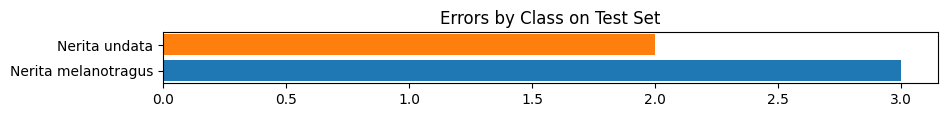

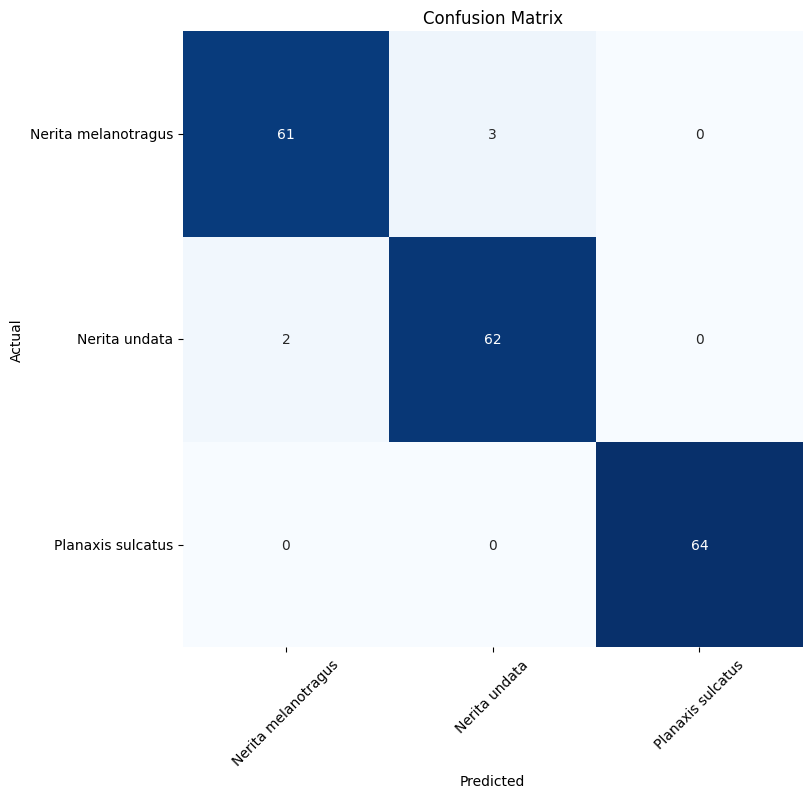

Classification Report:
----------------------
                      precision    recall  f1-score   support

Nerita melanotragus       0.97      0.95      0.96        64
      Nerita undata       0.95      0.97      0.96        64
  Planaxis sulcatus       1.00      1.00      1.00        64

           accuracy                           0.97       192
          macro avg       0.97      0.97      0.97       192
       weighted avg       0.97      0.97      0.97       192



In [14]:
print_code = 0
preds      = model.predict(test_gen)
print_info(test_gen, preds, print_code, save_dir, subject)

In [15]:
from sklearn.metrics import classification_report
import numpy as np

# ----------------------------------------------------
# 1. Ambil prediksi & label asli dari test set
# ----------------------------------------------------
y_true = np.array(test_gen.labels)
y_pred = np.argmax(preds, axis=1)

class_dict   = test_gen.class_indices
idx_to_class = {v: k for k, v in class_dict.items()}
classes      = [idx_to_class[i] for i in range(len(class_dict))]

# ----------------------------------------------------
# 2. Classification report dalam bentuk dict
# ----------------------------------------------------
report = classification_report(
    y_true, y_pred,
    target_names=classes,
    output_dict=True
)

overall_accuracy = report['accuracy']

classes_metrics = {}
for cls in classes:
    classes_metrics[cls] = {
        'precision': round(report[cls]['precision'], 4),
        'recall':    round(report[cls]['recall'], 4),
        'f1':        round(report[cls]['f1-score'], 4),
        'support':   int(report[cls]['support'])
    }

# ----------------------------------------------------
# 3. Best epoch (berdasarkan val_loss terendah)
# ----------------------------------------------------
val_losses   = history.history['val_loss']
val_accs     = history.history['val_accuracy']
train_accs   = history.history['accuracy']
train_losses = history.history['loss']

best_idx = int(np.argmin(val_losses))

best_epoch_info = {
    'epoch':          best_idx + 1,
    'val_accuracy':   round(val_accs[best_idx], 4),
    'val_loss':       round(val_losses[best_idx], 5),
    'train_accuracy': round(train_accs[best_idx], 4),
    'train_loss':     round(train_losses[best_idx], 4)
}

# ----------------------------------------------------
# 4. Gabungkan & simpan ke .txt
# ----------------------------------------------------
metrics_summary = {
    'accuracy':   round(overall_accuracy, 4),
    'classes':    classes_metrics,
    'best_epoch': best_epoch_info
}

save_dir    = '/kaggle/working/'
output_path = save_dir + 'klasifikasi_metrics.txt'

with open(output_path, 'w') as f:
    f.write(str(metrics_summary))

print(f"Metrics disimpan ke: {output_path}")
print(metrics_summary)

Metrics disimpan ke: /kaggle/working/klasifikasi_metrics.txt
{'accuracy': 0.974, 'classes': {'Nerita melanotragus': {'precision': 0.9683, 'recall': 0.9531, 'f1': 0.9606, 'support': 64}, 'Nerita undata': {'precision': 0.9538, 'recall': 0.9688, 'f1': 0.9612, 'support': 64}, 'Planaxis sulcatus': {'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'support': 64}}, 'best_epoch': {'epoch': 19, 'val_accuracy': 0.9686, 'val_loss': 0.05952, 'train_accuracy': 0.9809, 'train_loss': 0.0611}}
